<h3> Customer segmentation using clustering

In [2]:
pip install kmodes


Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette("rainbow")

plt.rcParams['figure.figsize']=(10,5)

In [14]:
data = pd.read_csv('datasets/clustering_data.csv')
data

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2
...,...,...,...,...,...,...,...,...,...,...,...
949,949,31,male,2,own,moderate,NaN,3621,24,radio/TV,2
950,950,40,male,0,own,little,moderate,3590,18,business,1
951,951,24,male,2,own,little,little,2145,36,business,2
952,952,28,female,2,rent,quite rich,moderate,4113,24,car,2


In [15]:
df = pd.read_csv('datasets/clustering_data.csv')
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     175
Checking account    378
Credit amount         0
Duration              0
Purpose               0
Credit Risk           0
dtype: int64

In [9]:
df.isnull().any()

Unnamed: 0          False
Age                 False
Sex                 False
Job                 False
Housing             False
Saving accounts      True
Checking account     True
Credit amount       False
Duration            False
Purpose             False
Credit Risk         False
dtype: bool

<h3>Selecting columns for clustering

In [19]:
selected_cols = ["Age","Credit amount","Duration"] ##for numerical features
cluster_data = df.loc[:,selected_cols]

In [20]:
print(cluster_data)

     Age  Credit amount  Duration
0     67           1169         6
1     22           5951        48
2     49           2096        12
3     45           7882        42
4     53           4870        24
..   ...            ...       ...
949   31           3621        24
950   40           3590        18
951   24           2145        36
952   28           4113        24
953   26          10974        36

[954 rows x 3 columns]


In [23]:
from mpl_toolkits.mplot3d import Axes3D

def _3d_data_plot(data, labels=None):
    """
    Wrapper for 3D data plot.

    Parameters:
    data: pandas DataFrame
        DataFrame containing the data to plot.
    labels: array-like, optional
        Labels of the data points (if available).
    """
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection="3d")
    g = ax.scatter(
        data["Credit amount"],
        data["Duration"],
        data["Age"],
        c=labels if labels is not None else 'black',
        cmap='rainbow'
    )
    ax.set_xlabel("Credit amount")
    ax.set_ylabel("Duration")
    ax.set_zlabel("Age")
    plt.tight_layout()
    plt.show()

def scatter_plot(data, hue=None):
    """
    Wrapper for seaborn scatter plot.

    Parameters:
    data: pandas DataFrame
        DataFrame containing the data to plot.
    hue: str, optional
        Variable to distinguish data points (optional).
    """
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8))
    sns.scatterplot(x="Credit amount", y="Duration", hue=hue, data=data, ax=ax1, palette='rainbow')
    sns.scatterplot(x="Age", y="Credit amount", hue=hue, data=data, ax=ax2, palette='rainbow')
    sns.scatterplot(x="Age", y="Duration", hue=hue, data=data, ax=ax3, palette='rainbow')
    plt.tight_layout()
    plt.show()

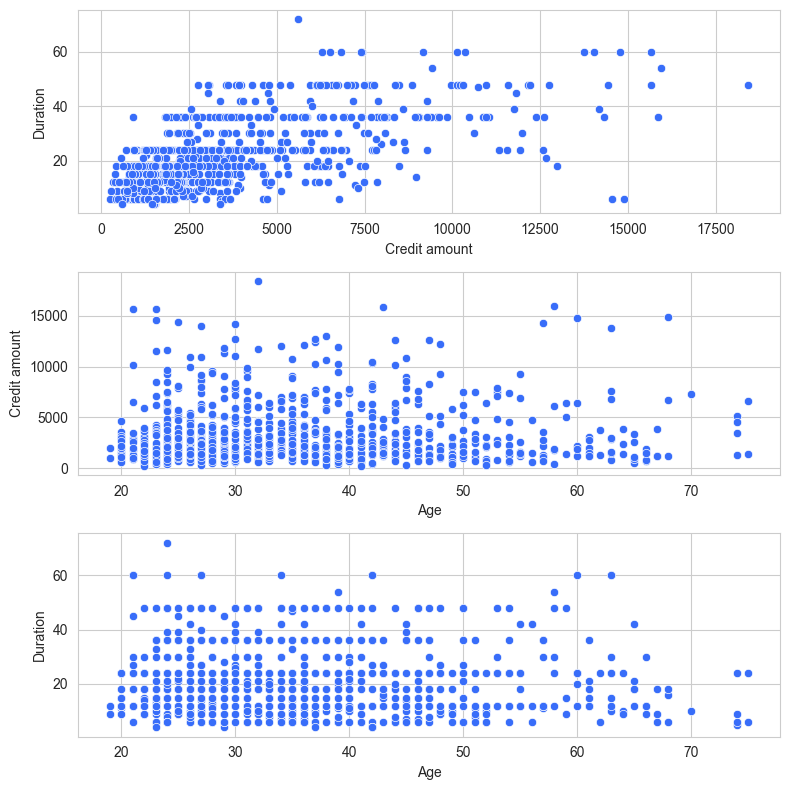

In [24]:
scatter_plot(cluster_data)

In [25]:
def box_plot(df):
    """
    Wrapper for box plotting.

    Parameters:
    df: pandas DataFrame
    """
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    sns.boxplot(df['Credit amount'], ax=ax[0])
    sns.boxplot(df['Duration'], ax=ax[1])
    sns.boxplot(df['Age'], ax=ax[2])
    plt.tight_layout()

def distributions_plot(df):
    """
    Wrapper for plotting data distributions.

    Parameters:
    df: pandas DataFrame
    """
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    sns.distplot(df['Age'], ax=ax[0])
    sns.distplot(df['Credit amount'], ax=ax[1])
    sns.distplot(df['Duration'], ax=ax[2])
    plt.tight_layout()

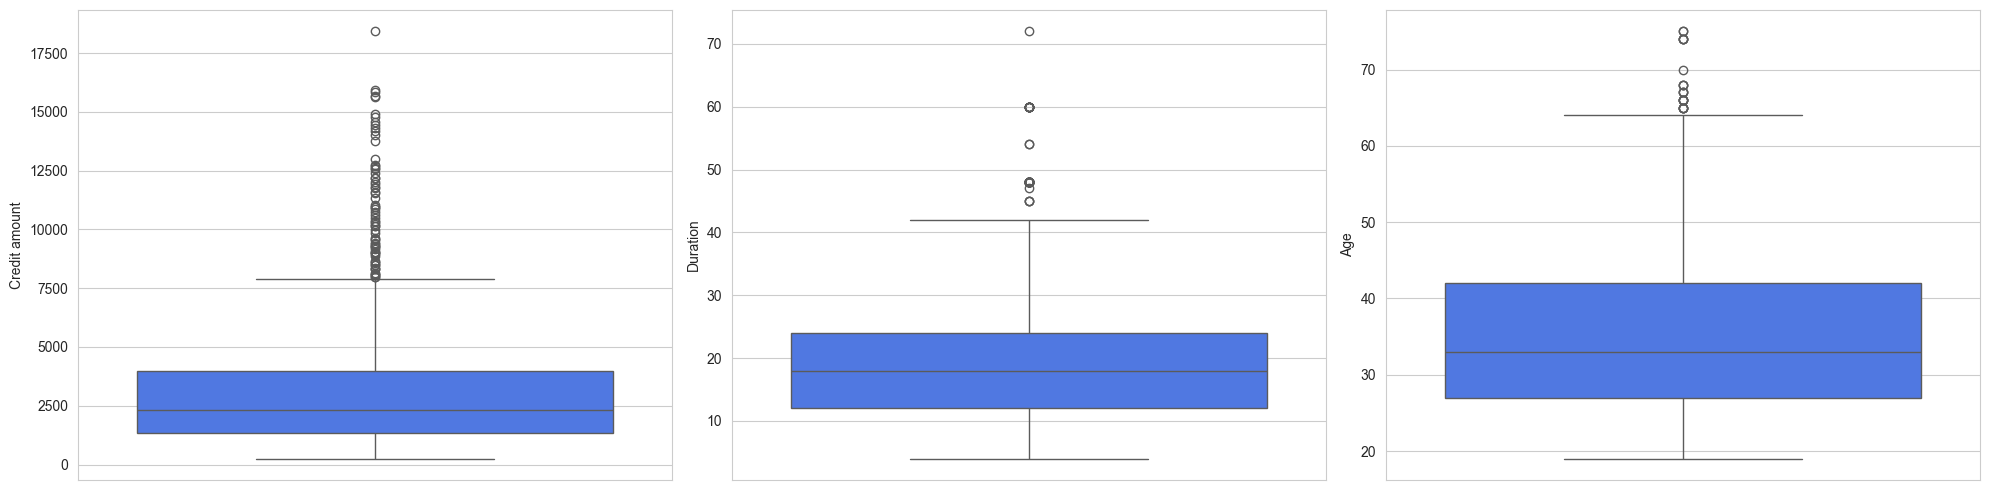

In [26]:
box_plot(cluster_data)

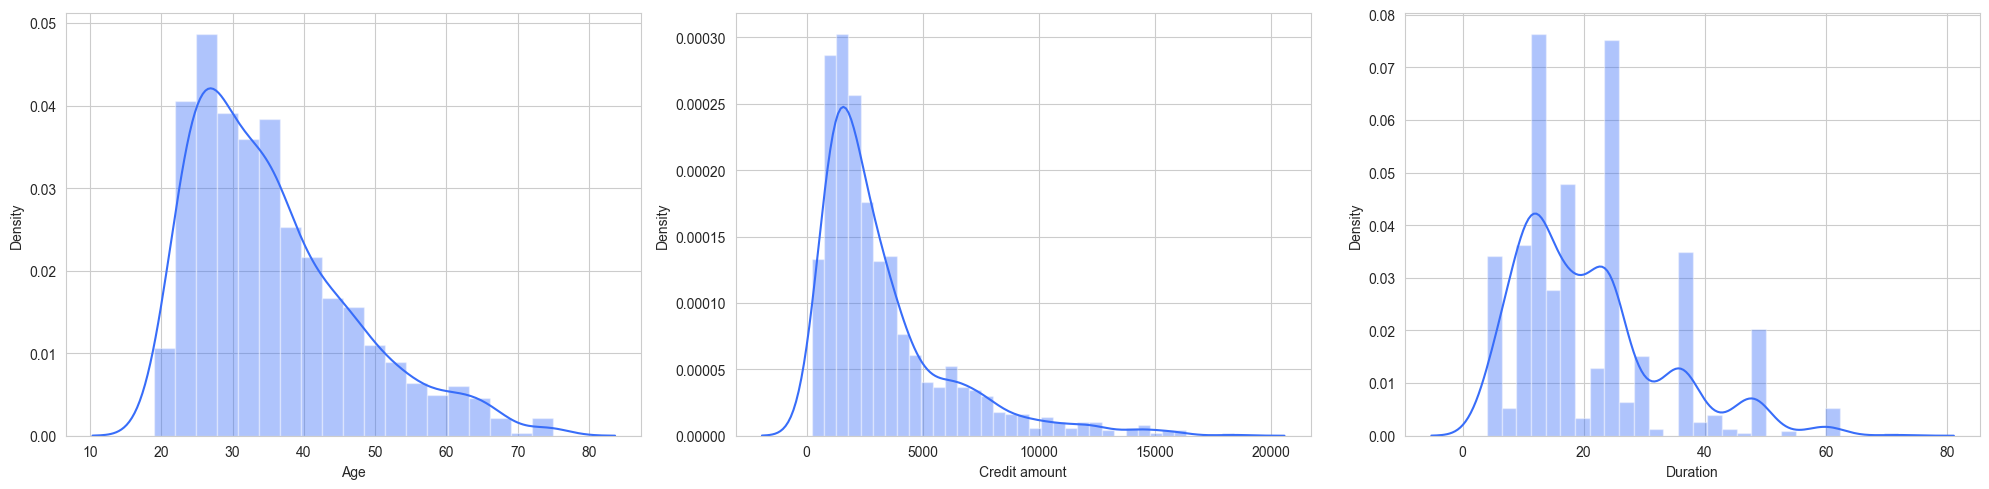

In [27]:
distributions_plot(cluster_data)